<a href="https://colab.research.google.com/github/jeongseoahn/VaR/blob/main/VaR2permanent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Parametric
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm
# yfinance를 통해 금융 데이터를 다운받는다
# datetime을 통해 날짜를 가져옴

years = 10
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days = 365*years)

tickers = ['VTI', 'TLT', 'BIL', 'GLD']

close_df = pd.DataFrame()
#종가로
for ticker in tickers:
    data = yf.download(ticker, start = startDate, end = endDate)

    close_df[ticker] = data['Close']

print(close_df)

/tmp/ipython-input-2902811942.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start = startDate, end = endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2902811942.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start = startDate, end = endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2902811942.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start = startDate, end = endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2902811942.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start = startDate, end = endDate)
[*********************100%***********************]  1 of 1 completed

                   VTI        TLT        BIL         GLD
Date                                                    
2015-08-12   91.055641  95.436523  76.018181  107.750000
2015-08-13   90.929024  95.128845  76.018181  106.860001
2015-08-14   91.275024  95.351944  76.001595  106.849998
2015-08-17   91.857307  95.782700  76.001595  107.129997
2015-08-18   91.621040  95.028854  76.018181  107.110001
...                ...        ...        ...         ...
2025-08-04  310.529999  88.059998  91.480003  310.910004
2025-08-05  309.160004  88.330002  91.480003  311.160004
2025-08-06  311.250000  87.820000  91.510002  310.500000
2025-08-07  311.070007  87.669998  91.510002  313.119995
2025-08-08  313.029999  87.290001  91.540001  313.049988

[2513 rows x 4 columns]


In [ ]:
#수익률은 일반 수익률이 아닌 로그 수익률을 사용
#로그 수익률은 덧셈으로 누적이 가능하고, 수학적으로 정규분포에 더 가까워 금융 모델에 적합하기 때문에 일반 수익률보다 더 많이 사용된다
log_returns = np.log(close_df / close_df.shift(1))
log_returns = log_returns.dropna()
print(log_returns)

                 VTI       TLT       BIL       GLD
Date                                              
2015-08-13 -0.001392 -0.003229  0.000000 -0.008294
2015-08-14  0.003798  0.002342 -0.000218 -0.000094
2015-08-17  0.006359  0.004507  0.000000  0.002617
2015-08-18 -0.002575 -0.007902  0.000218 -0.000187
2015-08-19 -0.008975  0.009827  0.000219  0.013355
...              ...       ...       ...       ...
2025-08-04  0.015545  0.002729  0.000109  0.005806
2025-08-05 -0.004422  0.003061  0.000000  0.000804
2025-08-06  0.006737 -0.005791  0.000328 -0.002123
2025-08-07 -0.000578 -0.001710  0.000000  0.008403
2025-08-08  0.006281 -0.004344  0.000328 -0.000224

[2512 rows x 4 columns]


In [ ]:
portfolio_value = 1000000 #단위:$
'''
#균등한 비율을 가정
weights = np.array([1/len(tickers)]*len(tickers))
print(weights)
'''
#지율 지정
tickers = ['VTI', 'TLT', 'BIL', 'GLD']
weights = np.array([0.25, 0.25, 0.25, 0.25])
print(weights)
print(np.sum(weights))  # 1.0이 출력되어야 한다


[0.25 0.25 0.25 0.25]
1.0


In [ ]:
historical_returns = (log_returns *weights).sum(axis =1)
print(historical_returns)
#axis=1 → 가로 방향(행별 합), 즉 같은 날짜별로 자산들의 수익률 합산

Date
2015-08-13   -0.003229
2015-08-14    0.001457
2015-08-17    0.003371
2015-08-18   -0.002611
2015-08-19    0.003607
                ...   
2025-08-04    0.006048
2025-08-05   -0.000139
2025-08-06   -0.000212
2025-08-07    0.001529
2025-08-08    0.000510
Length: 2512, dtype: float64


In [ ]:
days = 1
'''
historical_x_day_returns = historical_returns.rolling(window = days).sum()
print(historical_x_day_returns)
'''

'\nhistorical_x_day_returns = historical_returns.rolling(window = days).sum()\nprint(historical_x_day_returns)\n'

In [ ]:
cov_matrix = log_returns.cov() *252
print(cov_matrix)


          VTI       TLT       BIL       GLD
VTI  0.034939 -0.004951 -0.000004  0.001285
TLT -0.004951  0.022849  0.000003  0.006529
BIL -0.000004  0.000003  0.000007  0.000014
GLD  0.001285  0.006529  0.000014  0.020913


In [ ]:
portfolio_std_dev = np.sqrt(weights.T @ cov_matrix @ weights)
print(portfolio_std_dev)
#포트폴리오 분산 = (자산 A의 투자 비중)^2 × (자산 A의 분산) + (자산 B의 투자 비중)^2 × (자산 B의 분산) + 2 × (자산 A의 투자 비중) × (자산 B의 투자 비중) × (자산 A와 자산 B의 공분산)
#포트폴리오 분산 = wᵀ × Σ × w
'''
w (가중치 벡터)
각 자산에 얼마만큼 투자했는지 비율을 나타냄
Σ (공분산 행렬)
자산 각각의 변동성과, 서로의 관계(공분산)를 담은 표
Transpose (전치)
가중치 벡터는 기본적으로 세로로 생겼는데, 행렬 곱을 위해 가로로 눕혀야 함
그래서 먼저 가중치 벡터를 Transpose(전치)해서 가로로 만든 뒤 곱함
'''

0.072654323317825


'\nw (가중치 벡터)\n각 자산에 얼마만큼 투자했는지 비율을 나타냄\nΣ (공분산 행렬)\n자산 각각의 변동성과, 서로의 관계(공분산)를 담은 표\nTranspose (전치)\n가중치 벡터는 기본적으로 세로로 생겼는데, 행렬 곱을 위해 가로로 눕혀야 함\n그래서 먼저 가중치 벡터를 Transpose(전치)해서 가로로 만든 뒤 곱함\n'

In [ ]:

confidence_levels = [0.95]

In [ ]:
from scipy.stats import norm
VaRs = []

for cl in confidence_levels:
  VaR = portfolio_value * norm.ppf(cl) * portfolio_std_dev * np.sqrt(days/252)
  VaRs.append(VaR)
  #VaR = 포트폴리오 가치 × z(신뢰수준) × 포트폴리오 표준편차 × 제곱근(일수 ÷ 252)


print(VaRs)

[np.float64(7528.153201906126)]


In [ ]:
print(f'{"Confidence Level:"} {"Value at Risk:"}')

for cl, VaR in zip(confidence_levels, VaRs):
  print(f'{cl*100:.0f}%  {VaR:,.2f}')


Confidence Level: Value at Risk:
95%  7,528.15


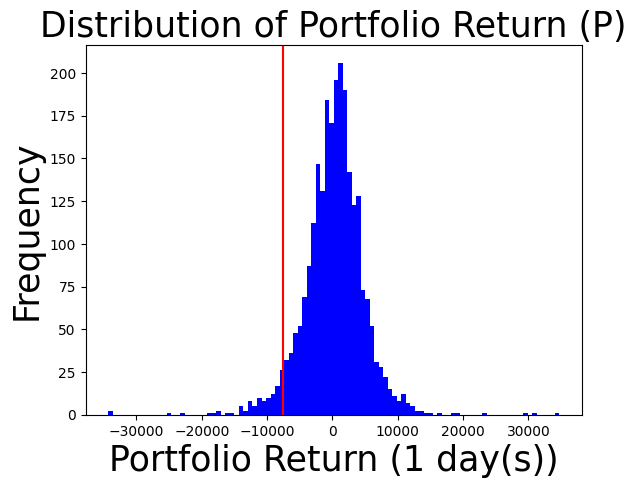

In [ ]:
historical_returns_dollar =historical_returns * portfolio_value
plt.hist(historical_returns_dollar, bins=100,  color='b', label=f'{days}- Day Returns')
for cl, VaR in zip(confidence_levels, VaRs):
  plt.axvline(x=-VaR, color='r', label='VaR at {}% Confidence'.format(int(cl * 100)))


plt.xlabel("Portfolio Return (%d day(s))" % (days),fontsize=25)
plt.ylabel('Frequency',fontsize=25)

plt.title("Distribution of Portfolio Return (P)",fontsize=25)
#plt.legend()
plt.show()

In [ ]:
#Historical
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

years = 10
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days = 365*years)


tickers = ['VTI', 'TLT', 'BIL', 'GLD']

adj_close_df = pd.DataFrame()

for ticker in tickers:
    data = yf.download(ticker, start = startDate, end = endDate)
    close_df[ticker] = data['Close']

print(close_df)

/tmp/ipython-input-1947674493.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start = startDate, end = endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1947674493.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start = startDate, end = endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1947674493.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start = startDate, end = endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1947674493.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start = startDate, end = endDate)
[*********************100%***********************]  1 of 1 completed

                   VTI        TLT        BIL         GLD
Date                                                    
2015-08-12   91.055618  95.436554  76.018204  107.750000
2015-08-13   90.929047  95.128845  76.018204  106.860001
2015-08-14   91.275017  95.351944  76.001587  106.849998
2015-08-17   91.857300  95.782707  76.001587  107.129997
2015-08-18   91.621033  95.028847  76.018204  107.110001
...                ...        ...        ...         ...
2025-08-04  310.529999  88.059998  91.480003  310.910004
2025-08-05  309.160004  88.330002  91.480003  311.160004
2025-08-06  311.250000  87.820000  91.510002  310.500000
2025-08-07  311.070007  87.669998  91.510002  313.119995
2025-08-08  313.029999  87.290001  91.540001  313.049988

[2513 rows x 4 columns]


In [ ]:
log_returns = np.log(close_df / close_df.shift(1))
log_returns = log_returns.dropna()
print(log_returns)

                 VTI       TLT       BIL       GLD
Date                                              
2015-08-13 -0.001391 -0.003229  0.000000 -0.008294
2015-08-14  0.003798  0.002342 -0.000219 -0.000094
2015-08-17  0.006359  0.004507  0.000000  0.002617
2015-08-18 -0.002575 -0.007902  0.000219 -0.000187
2015-08-19 -0.008975  0.009827  0.000219  0.013355
...              ...       ...       ...       ...
2025-08-04  0.015545  0.002729  0.000109  0.005806
2025-08-05 -0.004422  0.003061  0.000000  0.000804
2025-08-06  0.006737 -0.005791  0.000328 -0.002123
2025-08-07 -0.000578 -0.001710  0.000000  0.008403
2025-08-08  0.006281 -0.004344  0.000328 -0.000224

[2512 rows x 4 columns]


In [ ]:
portfolio_value = 1000000 #단위:$
'''
#균등한 비율을 가정
weights = np.array([1/len(tickers)]*len(tickers))
print(weights)
'''
#지율 지정
tickers = ['VTI', 'TLT', 'BIL', 'GLD']

weights = np.array([0.25, 0.25, 0.25, 0.25])
print(weights)
print(np.sum(weights))  # 1.0이 출력되어야 한다


[0.25 0.25 0.25 0.25]
1.0


In [ ]:
historical_returns = (log_returns *weights).sum(axis =1)
print(historical_returns)


Date
2015-08-13   -0.003229
2015-08-14    0.001457
2015-08-17    0.003371
2015-08-18   -0.002611
2015-08-19    0.003606
                ...   
2025-08-04    0.006048
2025-08-05   -0.000139
2025-08-06   -0.000212
2025-08-07    0.001529
2025-08-08    0.000510
Length: 2512, dtype: float64


In [ ]:
days = 1
'''
range_returns = historical_returns.rolling(window = days).sum()
range_returns = range_returns.dropna()
print(range_returns)
'''

'\nrange_returns = historical_returns.rolling(window = days).sum()\nrange_returns = range_returns.dropna()\nprint(range_returns)\n'

In [ ]:
confidence_interval = 0.95
VaR = -np.percentile(historical_returns, 100 - (confidence_interval * 100)) * portfolio_value
print(VaR)


7049.967150393224


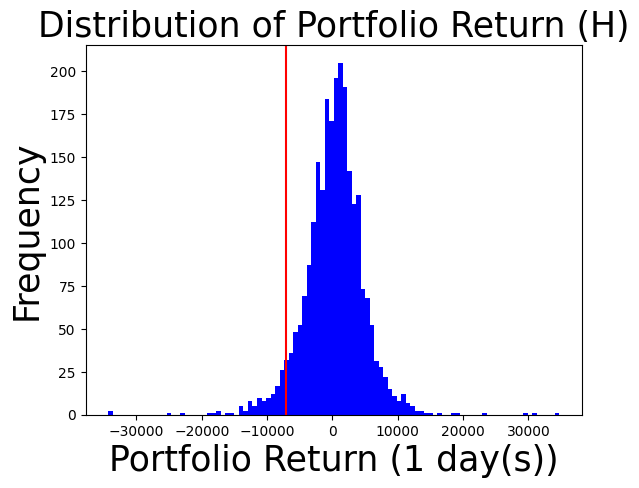

In [ ]:
'''
return_window = days
range_returns = historical_returns.rolling(window=return_window).sum()
range_returns = range_returns.dropna()
'''
historical_returns_dollar = historical_returns * portfolio_value

plt.hist(historical_returns_dollar.dropna(),color='b', bins=100)

plt.xlabel("Portfolio Return (%d day(s))" % (days),fontsize=25)
plt.ylabel('Frequency',fontsize=25)
plt.title("Distribution of Portfolio Return (H)",fontsize=25)
plt.axvline(-VaR, color='r', label=f'VaR at {confidence_interval:.0%} confidence level')
#plt.legend()
plt.show()

In [ ]:
#MonteCarlo
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

years = 10
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days = 365*years)


tickers = ['VTI', 'TLT', 'BIL', 'GLD']

close_df = pd.DataFrame()

for ticker in tickers:
    data = yf.download(ticker, start = startDate, end = endDate)

    close_df[ticker] = data['Close']

print(close_df)

/tmp/ipython-input-2084760551.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start = startDate, end = endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2084760551.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start = startDate, end = endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2084760551.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start = startDate, end = endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2084760551.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start = startDate, end = endDate)
[*********************100%***********************]  1 of 1 completed

                   VTI        TLT        BIL         GLD
Date                                                    
2015-08-12   91.055634  95.436531  76.018227  107.750000
2015-08-13   90.929047  95.128876  76.018227  106.860001
2015-08-14   91.275070  95.351944  76.001556  106.849998
2015-08-17   91.857300  95.782684  76.001556  107.129997
2015-08-18   91.621040  95.028893  76.018227  107.110001
...                ...        ...        ...         ...
2025-08-04  310.529999  88.059998  91.480003  310.910004
2025-08-05  309.160004  88.330002  91.480003  311.160004
2025-08-06  311.250000  87.820000  91.510002  310.500000
2025-08-07  311.070007  87.669998  91.510002  313.119995
2025-08-08  313.029999  87.290001  91.540001  313.049988

[2513 rows x 4 columns]


In [ ]:
log_returns = np.log(close_df / close_df.shift(1))
log_returns = log_returns.dropna()
print(log_returns)

                 VTI       TLT       BIL       GLD
Date                                              
2015-08-13 -0.001391 -0.003229  0.000000 -0.008294
2015-08-14  0.003798  0.002342 -0.000219 -0.000094
2015-08-17  0.006359  0.004507  0.000000  0.002617
2015-08-18 -0.002575 -0.007901  0.000219 -0.000187
2015-08-19 -0.008974  0.009827  0.000218  0.013355
...              ...       ...       ...       ...
2025-08-04  0.015545  0.002729  0.000109  0.005806
2025-08-05 -0.004422  0.003061  0.000000  0.000804
2025-08-06  0.006737 -0.005791  0.000328 -0.002123
2025-08-07 -0.000578 -0.001710  0.000000  0.008403
2025-08-08  0.006281 -0.004344  0.000328 -0.000224

[2512 rows x 4 columns]


In [ ]:
def expected_return(weights, log_returns):
  return np.sum(log_returns.mean() * weights)

In [ ]:
def standard_deviation(weights, cov_matrix):
  variance = weights.T @ cov_matrix @ weights
  return np.sqrt(variance)

In [ ]:
cov_matrix = log_returns.cov()
print(cov_matrix)

              VTI           TLT           BIL           GLD
VTI  1.386478e-04 -1.964619e-05 -1.677619e-08  5.099055e-06
TLT -1.964619e-05  9.066980e-05  1.132066e-08  2.590741e-05
BIL -1.677619e-08  1.132066e-08  2.754573e-08  5.461895e-08
GLD  5.099055e-06  2.590741e-05  5.461895e-08  8.298839e-05


In [ ]:
portfolio_value = 1000000 #단위:$
'''
#균등한 비율을 가정
weights = np.array([1/len(tickers)]*len(tickers))
print(weights)
'''
#지율 지정
tickers = ['VTI', 'TLT', 'BIL', 'GLD']
weights = np.array([0.25, 0.25, 0.25, 0.25])
print(weights)
print(np.sum(weights))  # 1.0이 출력되어야 한다


portfolio_expected_return = expected_return(weights,log_returns)


portfolio_std_dev = standard_deviation(weights, cov_matrix)
print(portfolio_expected_return)
print(portfolio_std_dev)
print(weights)


[0.25 0.25 0.25 0.25]
1.0
0.0002386499705518448
0.004576792272610188
[0.25 0.25 0.25 0.25]


In [ ]:

np.random.seed(1)  # 시드 설정

def random_z_score():
    return np.random.normal(0, 1)
print(random_z_score())


1.6243453636632417


In [ ]:
days = 1

def scenario_gain_loss(portfolio_value, portfolio_std_dev, z_score , days):
  return portfolio_value* portfolio_expected_return * days + portfolio_value * portfolio_std_dev * z_score * np.sqrt(days)

In [ ]:
simulations = 10000
scenarioReturn =[]
for i in range(simulations):
  z_score = random_z_score()
  scenarioReturn.append(scenario_gain_loss(portfolio_value, portfolio_std_dev, z_score, days))


In [ ]:
confidence_interval = 0.95
VaR = -np.percentile(scenarioReturn, 100*(1 - confidence_interval))
print(VaR)

7173.8861486609485


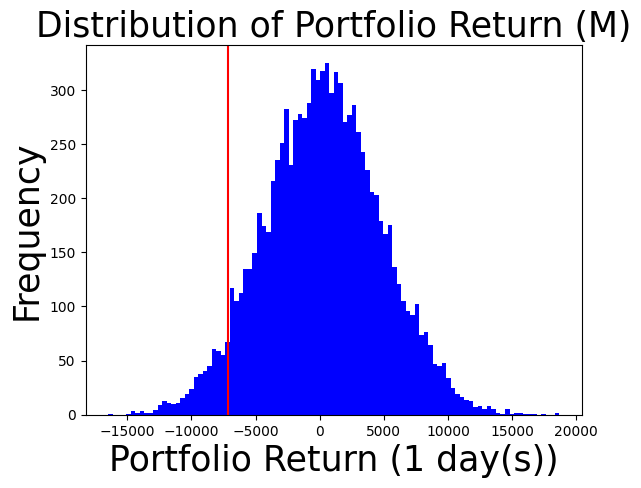

In [ ]:

plt.hist(scenarioReturn, bins=100, color='b')

plt.xlabel("Portfolio Return (%d day(s))" % (days),fontsize=25)
plt.ylabel('Frequency',fontsize=25)
plt.title("Distribution of Portfolio Return (M)",fontsize=25)
plt.axvline(-VaR, color='r', label=f'VaR at {confidence_interval:.0%} confidence level')
#plt.legend()
plt.show()